# H1 — Génération de mélodies par programmation par contraintes

**Auteurs** : *Samuel Krief et Nicolas Teisseire*
---

Dans ce notebook, on génère des mélodies qui respectent les règles de base de la musique tonale, en utilisant **OR-Tools CP-SAT**. Le code est dans le package `melody/`. 

## Plan

1. Le problème en CSP — variables, domaines, contraintes
2. Un peu de théorie musicale
3. Premier modèle : hard constraints seules
4. Soft constraints et profils stylistiques
5. Démo : génération et écoute

## 1. Le problème en CSP

On veut générer une suite de $n$ notes. Pour chaque note, on doit choisir une **hauteur**. Une mélodie est valide si elle respecte un ensemble de règles musicales (rester dans la gamme, ne pas faire de sauts trop grands, finir sur la tonique, etc.).

C'est exactement un **CSP** (cf. notebook CSP-1 du cours) :

- **Variables** $X = \{p_0, p_1, \dots, p_{n-1}\}$ — une variable entière par position de note.
- **Domaines** $D_t$ — l'ensemble des hauteurs MIDI possibles pour $p_t$.
- **Contraintes** $C$ — les règles musicales.

### Pourquoi CSP plutôt qu'autre chose ?

On aurait pu :
- générer aléatoirement et filtrer → trop d'échecs, l'espace est gigantesque
- utiliser un modèle génératif → pas de garantie sur les règles

**Un solveur CP garantit que toute mélodie produite respecte les règles**. C'est la propriété fondamentale qu'on met en avant.

### Taille de l'espace

Calculons concrètement combien de mélodies sont *a priori* possibles, et combien restent après chaque contrainte. C'est pédagogiquement très parlant.

In [2]:
import math

import sys
import os

sys.path.insert(0, os.path.abspath('..'))

n = 16              # longueur de la melodie
tessitura = 25      # nombre de hauteurs MIDI dans la plage Sol3 -> Sol5
in_scale = 15       # parmi ces 25, environ 15 sont dans la gamme de Do majeur

print(f'Sans contrainte         : {tessitura**n:e} melodies possibles')
print(f'Avec contrainte gamme   : {in_scale**n:e}')
print(f'Avec contrainte intervalle (approx) : {in_scale * 8**(n-1):e}')
print(f'Avec debut/fin fixes    : {1 * 8**(n-1) * (1/3):e}  # tres approx')


Sans contrainte         : 2.328306e+22 melodies possibles
Avec contrainte gamme   : 6.568408e+18
Avec contrainte intervalle (approx) : 5.277656e+14
Avec debut/fin fixes    : 1.172812e+13  # tres approx


On passe d'environ $10^{22}$ mélodies possibles à $10^{13}$ après application des contraintes les plus structurantes — soit un facteur de réduction d'environ $10^9$.

Le solveur CP-SAT exploite ces réductions par **propagation** : dès qu'on fixe une note, il élimine automatiquement les valeurs des autres variables qui deviennent impossibles.

## 2. Théorie musicale

Trois concepts suffisent pour comprendre le projet.

### Hauteurs MIDI

MIDI numérote chaque note de 0 à 127. **Do central = 60**. Chaque +1 = un demi-ton. Une octave = 12 demi-tons.

On définit le **pitch class** d'une note comme `pitch % 12`, cad 0 pour tous les Do, 7 pour tous les Sol, etc.

### Gamme

Une gamme est un sous-ensemble de 7 pitch classes sur les 12 possibles. En Do majeur : `{0, 2, 4, 5, 7, 9, 11}` = Do, Ré, Mi, Fa, Sol, La, Si.

**Toute note de la mélodie doit appartenir à la gamme**. C'est notre contrainte la plus importante.

### Degrés et cadence finale

Dans une gamme, chaque note a un rôle :

| Degré | Rôle |
|---|---|
| I (tonique) | stable, conclusif |
| V (dominante) | tendu, appelle la tonique |
| VII (sensible) | sous la tonique, veut y monter |

Une mélodie qui *sonne finie* termine par **V → I** ou **VII → I**. On ajoutera donc une contrainte sur les deux dernières notes.

## 3. Premier modèle : hard constraints seules

On commence par le modèle minimal. Hard constraints uniquement, pas d'optimisation. Le solveur trouve **n'importe quelle** mélodie valide.

### Les hard constraints implémentées

Toutes dans `melody/solver.py`, fonction `build_model()`.

| # | Contrainte | Formulation CP |
|---|---|---|
| C1 | Première note = tonique | `pitch[0] % 12 == 0` (en Do majeur) |
| C2 | Dernière note = tonique | `pitch[-1] % 12 == 0` |
| C3 | Avant-dernière = V ou VII | `pitch[-2] % 12 ∈ {7, 11}` (cadence) |
| C4 | Sauts ≤ une quinte | `abs(pitch[t+1] - pitch[t]) <= 7` |
| C5 | Pas deux notes identiques consécutives | `abs(pitch[t+1] - pitch[t]) >= 1` |
| C6 | **Pas de triton** | `abs(pitch[t+1] - pitch[t]) != 6` |

C1, C2, C3 sont encodées avec `AddAllowedAssignments` CSP-1.
C4, C5 et C6 utilisent `AddAbsEquality`, présentée dans CSP-5.

### Pourquoi interdire le triton (C6) ?

Le **triton** est un intervalle de 6 demi-tons (par exemple Do → Fa#). C'est historiquement l'intervalle le plus dissonant de la musique tonale — au Moyen-Âge, l'Église l'avait surnommé *diabolus in musica* (« le diable en musique ») et l'interdisait dans la musique liturgique. Le bannir donne immédiatement un caractère plus consonant aux mélodies.

Le domaine de chaque variable est déjà restreint à la gamme donc on évite ainsi de poser la contrainte `pitch % 12 in scale` explicitement, ce qui rend le solveur beaucoup plus rapide.

In [3]:
from melody.solver import build_model
from ortools.sat.python import cp_model

model, pitch = build_model(n_notes=12, scale_name='C_major')

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 5.0
status = solver.Solve(model)

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    raw_melody = [solver.Value(p) for p in pitch]
    from melody.export import to_text
    print('Melodie sans soft constraints :')
    print(to_text(raw_melody))
else:
    print('Pas de solution.')


Melodie sans soft constraints :
C4 A3 B3 C4 B3 C4 B3 C4 B3 C4 B3 C4


Cette mélodie respecte toutes les hard constraints, mais elle est probablement laide : elle peut osciller bêtement, rester sur 2-3 notes, etc. C'est ce qu'on attend d'un solveur qui n'a aucune préférence : il prend **la première solution qu'il trouve**.

Pour obtenir de la **musique**, il nous faut des **préférences**. C'est le rôle des soft constraints.

## 4. Soft constraints et profils stylistiques

Une **soft constraint** est une préférence : on ne l'impose pas, mais on paye un coût si elle est violée. Le solveur cherche alors une solution qui **minimise** la somme des coûts.

C'est exactement le **Weighted CSP** du notebook CSP-7. Formellement, on a :

$$\min \sum_i w_i \cdot \text{violation}_i$$

où $w_i$ est le poids de la $i$-ème préférence.

### Les 6 soft constraints implémentées

Toutes dans `melody/solver.py`.

**Préférences mélodiques élémentaires** :

1. **`smoothness`** — pénalise les sauts > 2 demi-tons. Cost = `max(0, |intervalle| - 2) × weight`.
2. **`range`** — pénalise un ambitus trop petit (< 1 octave). Cost = `max(0, 12 - ambitus) × weight`.
3. **`direction`** — pénalise les directions répétées. Cost = `weight` par continuité.
4. **`no_oscillation`** — pénalise les motifs A-B-A (`pitch[t+2] == pitch[t]`). Évite les oscillations.

**Préférences structurelles plus avancées**:

5. **`strong_beat`** — pénalise les notes dissonantes sur les temps forts. Sur les positions paires (0, 2, 4, …), on préfère la triade tonique (I-III-V, soit Do-Mi-Sol en Do majeur), qui est l'accord parfait. Cost = `weight`.

6. **`arch`** — favorise un contour mélodique en arche. Une mélodie « naturelle » monte progressivement vers un sommet placé aux **2/3** de la phrase, puis redescend vers la cadence finale.

### Les 3 profils stylistiques

Chaque profil est une combinaison de poids — on enrichit la table avec les nouvelles préférences :

| Profil | smoothness | range | direction | no_oscillation | strong_beat | arch | Effet attendu |
|---|---|---|---|---|---|---|---|
| **fluide** | 5 | 1 | 1 | 3 | 4 | 3 | Style classique, arche en milieu de phrase, fortes consonances |
| **aventureux** | 1 | 5 | 3 | 2 | 1 | 1 | Sauts autorisés, large ambitus, contour libre |
| **minimaliste** | 3 | 0 | 0 | 1 | 2 | 0 | Stable, sobre, sans direction marquée |

**C'est ici que se joue le côté "musical" du projet.** En changeant uniquement les coefficients, on obtient des styles différents. C'est la démonstration scientifique principale : *les soft constraints permettent de paramétrer le style sans changer le modèle*.

In [4]:
from melody import solve, to_text, PROFILES

print('Comparaison des 3 profils sur 16 notes en Do majeur :')
print('=' * 60)
for profile in PROFILES:
    m = solve(n_notes=16, scale_name='C_major', profile=profile, random_seed=42)
    print(f'\n[{profile:12s}] {to_text(m)}')
    intervals = [abs(m[t+1] - m[t]) for t in range(len(m)-1)]
    print(f'              ambitus = {max(m) - min(m)} demi-tons, '
          f'saut moyen = {sum(intervals)/len(intervals):.1f}')


Comparaison des 3 profils sur 16 notes en Do majeur :

[fluide      ] C4 D4 E4 F4 G4 F4 E4 D4 C4 D4 E4 F4 G4 A4 B4 C5
              ambitus = 12 demi-tons, saut moyen = 1.7

[aventureux  ] C5 D5 B4 C5 A4 B4 G4 A4 F4 G4 E4 F4 C4 D4 B3 C4
              ambitus = 15 demi-tons, saut moyen = 2.5

[minimaliste ] C4 D4 E4 F4 G4 F4 E4 D4 C4 D4 E4 F4 G4 A4 B4 C5
              ambitus = 12 demi-tons, saut moyen = 1.7


## 5. Démo : visualisation et écoute

On génère plusieurs mélodies différentes, on les affiche en **piano roll** et on exporte des fichiers MIDI écoutables.

### Eviter les solutions identiques

Quand on relance le solveur avec les mêmes paramètres, il a tendance à retomber sur la même solution (la première mélodie optimale trouvée). Pour obtenir de la diversité, on utilise `solve_many()` qui ajoute après chaque solution une contrainte interdisant cette mélodie exacte. Le solveur est alors forcé d'en chercher une autre.

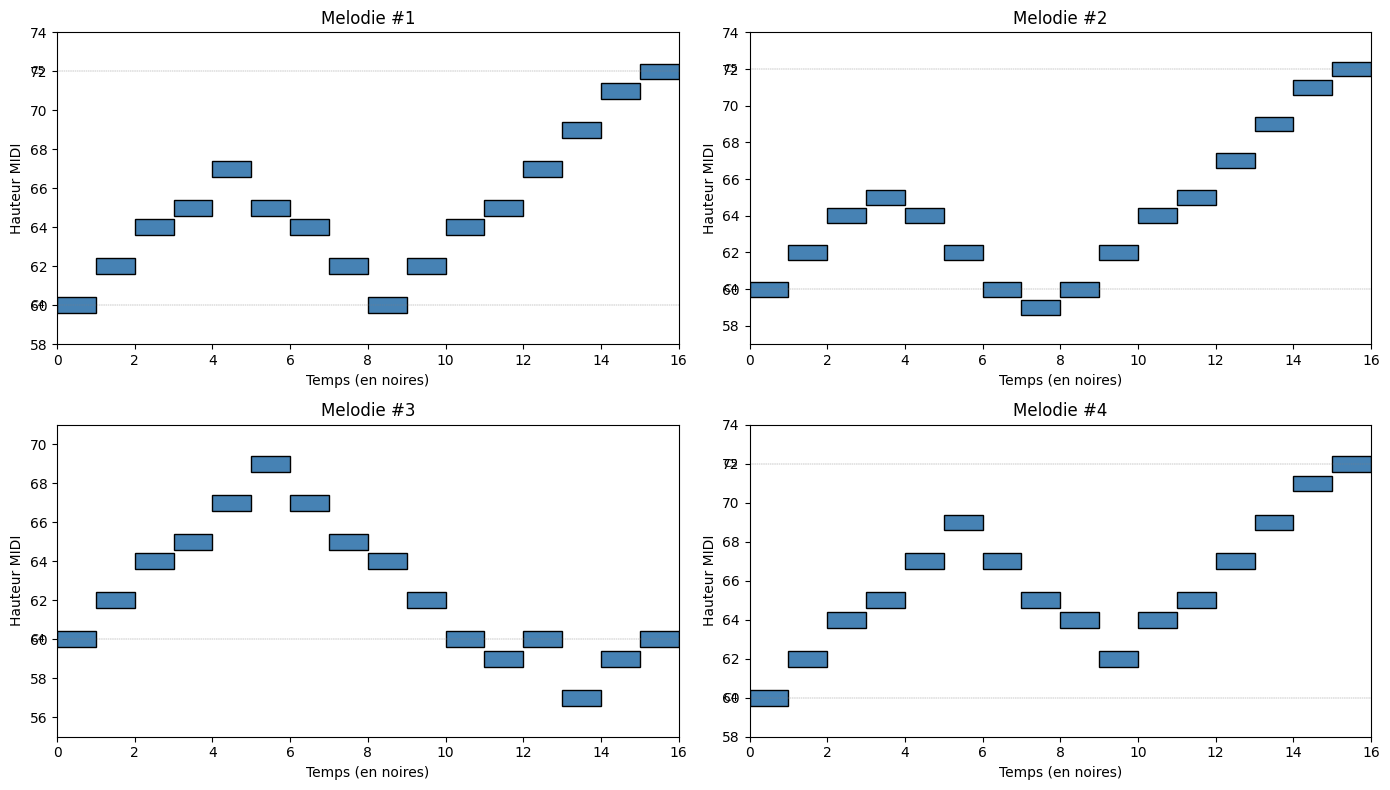

In [5]:
import matplotlib.pyplot as plt
from melody import solve_many, plot_piano_roll, to_midi

melodies = solve_many(n=4, n_notes=16, scale_name='C_major', profile='fluide', time_limit=3.0)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (m, ax) in enumerate(zip(melodies, axes.flat)):
    plot_piano_roll(m, title=f'Melodie #{i+1}', ax=ax)
plt.tight_layout()
plt.show()


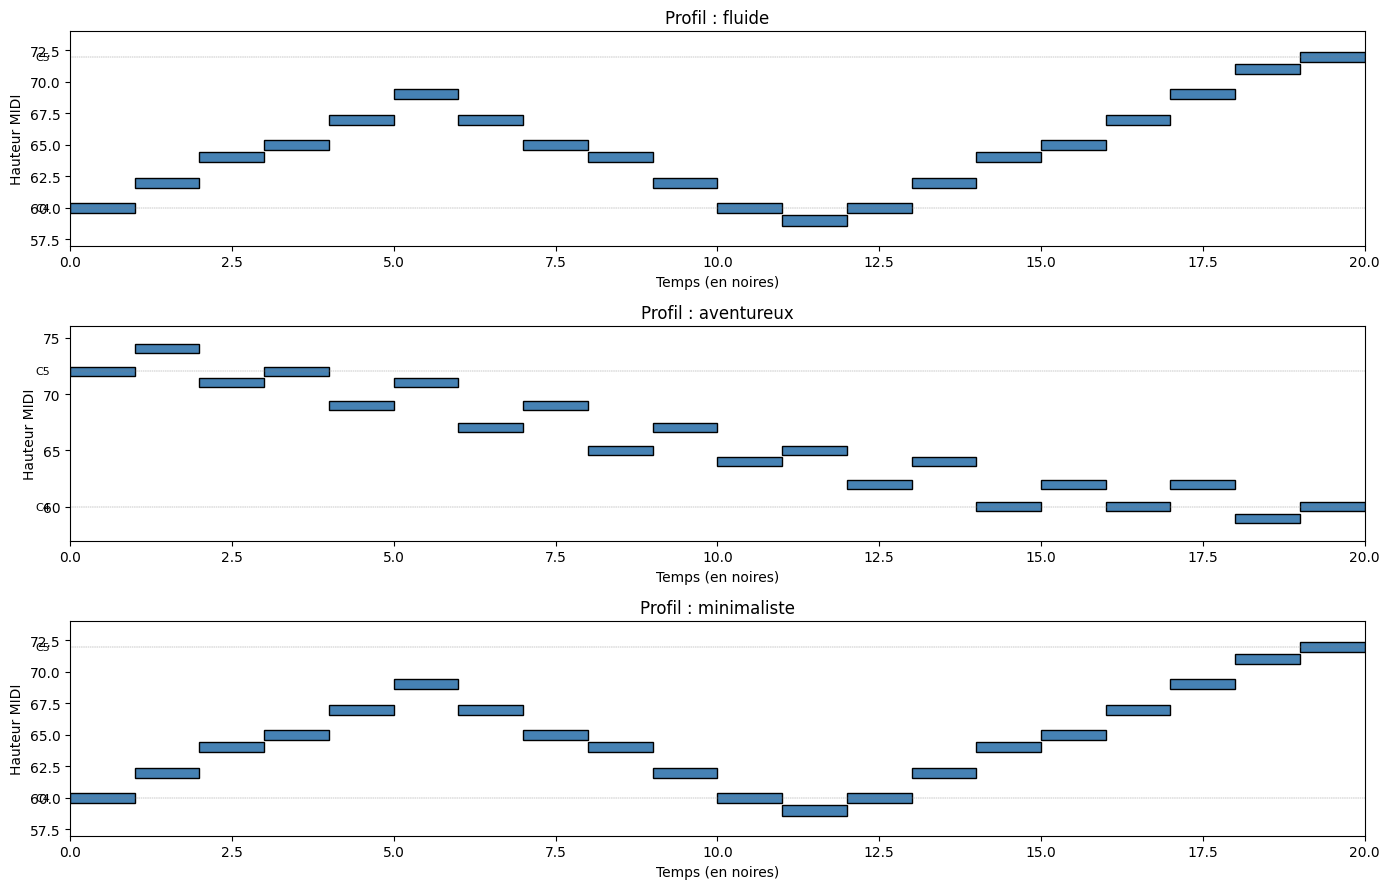

In [5]:
# Comparaison des 3 profils sur la meme longueur
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, profile in zip(axes, PROFILES):
    m = solve(n_notes=20, scale_name='C_major', profile=profile, random_seed=11)
    plot_piano_roll(m, title=f'Profil : {profile}', ax=ax)
plt.tight_layout()
plt.show()


In [6]:
import os
os.makedirs('outputs', exist_ok=True)

for profile in PROFILES:
    m = solve(n_notes=24, scale_name='C_major', profile=profile, random_seed=7)
    path = f'outputs/demo_{profile}.mid'
    to_midi(m, path, tempo=110)
    print(f'Genere : {path}')
print()
print('Ces fichiers s\'ouvrent avec VLC, MuseScore, ou sur https://cifkao.github.io/html-midi-player/')


Genere : outputs/demo_fluide.mid
Genere : outputs/demo_aventureux.mid
Genere : outputs/demo_minimaliste.mid

Ces fichiers s'ouvrent avec VLC, MuseScore, ou sur https://cifkao.github.io/html-midi-player/


## 6. Export ABC : partition lisible et imprimable

Le MIDI permet d'**écouter** la mélodie, mais c'est un fichier binaire — impossible de le lire à l'œil ou de l'imprimer comme une partition. Pour ça, on utilise un format complémentaire : la **notation ABC**.

ABC est un format **texte** standard, lisible et compact, qu'on peut rendre en vraie partition graphique via le site https://www.abcjs.net/.


### Règles de conversion MIDI → ABC

| Octave MIDI | Notation ABC | Exemple |
|---|---|---|
| Octave 4 (60-71) | majuscules | `C D E F G A B` |
| Octave 5 (72-83) | minuscules | `c d e f g a b` |
| Octave 3 (48-59) | majuscules + `,` | `C, D, E,` |
| Octave 6+ | minuscules + `'` | `c' d' e'` |

C'est `to_abc()` qui fait ce travail dans `export.py`.


In [ ]:
from melody import solve, to_abc, save_abc, to_text

# Generer une melodie et la convertir en ABC
melody = solve(n_notes=16, scale_name='C_major', profile='fluide', random_seed=7)
print('Melodie en MIDI:', to_text(melody))
print()
print('--- Partition au format ABC ---')
abc = to_abc(melody, title='Demo fluide en Do majeur')
print(abc)
print()
print('Pour visualiser comme une vraie partition :')
print('1. Copier le texte ABC ci-dessus')
print('2. Coller sur https://www.abcjs.net/abcjs-editor.html')
print()

# Sauver aussi en fichier pour le rendu
import os
os.makedirs('outputs', exist_ok=True)
save_abc(melody, 'outputs/demo_fluide.abc', title='Demo fluide')
print('outputs/demo_fluide.abc')


Melodie en MIDI: C4 D4 E4 F4 E4 D4 C4 B3 C4 D4 E4 F4 G4 A4 B4 C5

--- Partition au format ABC ---
X:1
T:Demo fluide en Do majeur
M:4/4
L:1/4
Q:1/4=100
K:C
C D E F | E D C B, | C D E F | G A B c |

Pour visualiser comme une vraie partition :
1. Copier le texte ABC ci-dessus
2. Coller sur https://www.abcjs.net/abcjs-editor.html

Fichier ABC sauve : outputs/demo_fluide.abc


## 7. Mode variation : compléter une mélodie partielle

Jusqu'ici on a généré des mélodies *from-scratch*. Mais on peut aussi résoudre le **problème inverse** : partant d'une mélodie incomplète (certaines notes fixées, d'autres à `None`), on demande au solveur de **compléter les trous** en respectant toutes les contraintes.

### Démo

On génère un thème, on garde les notes "pivots" (positions 0, 4, 8, 12, 14, 15 — soit le début, les temps forts, et la cadence finale), et on demande 3 variations différentes.


Theme original : C4 D4 E4 F4 E4 D4 C4 B3 C4 D4 E4 F4 G4 A4 B4 C5

Positions pivots gardees : [0, 4, 8, 12, 14, 15]

Variation 1 : C4 B3 C4 D4 E4 F4 E4 D4 C4 D4 E4 F4 G4 A4 B4 C5
  -> 6/6 pivots respectes

Variation 2 : C4 B3 C4 D4 E4 D4 C4 B3 C4 D4 E4 F4 G4 A4 B4 C5
  -> 6/6 pivots respectes

Variation 3 : C4 D4 C4 D4 E4 F4 E4 D4 C4 D4 E4 F4 G4 A4 B4 C5
  -> 6/6 pivots respectes



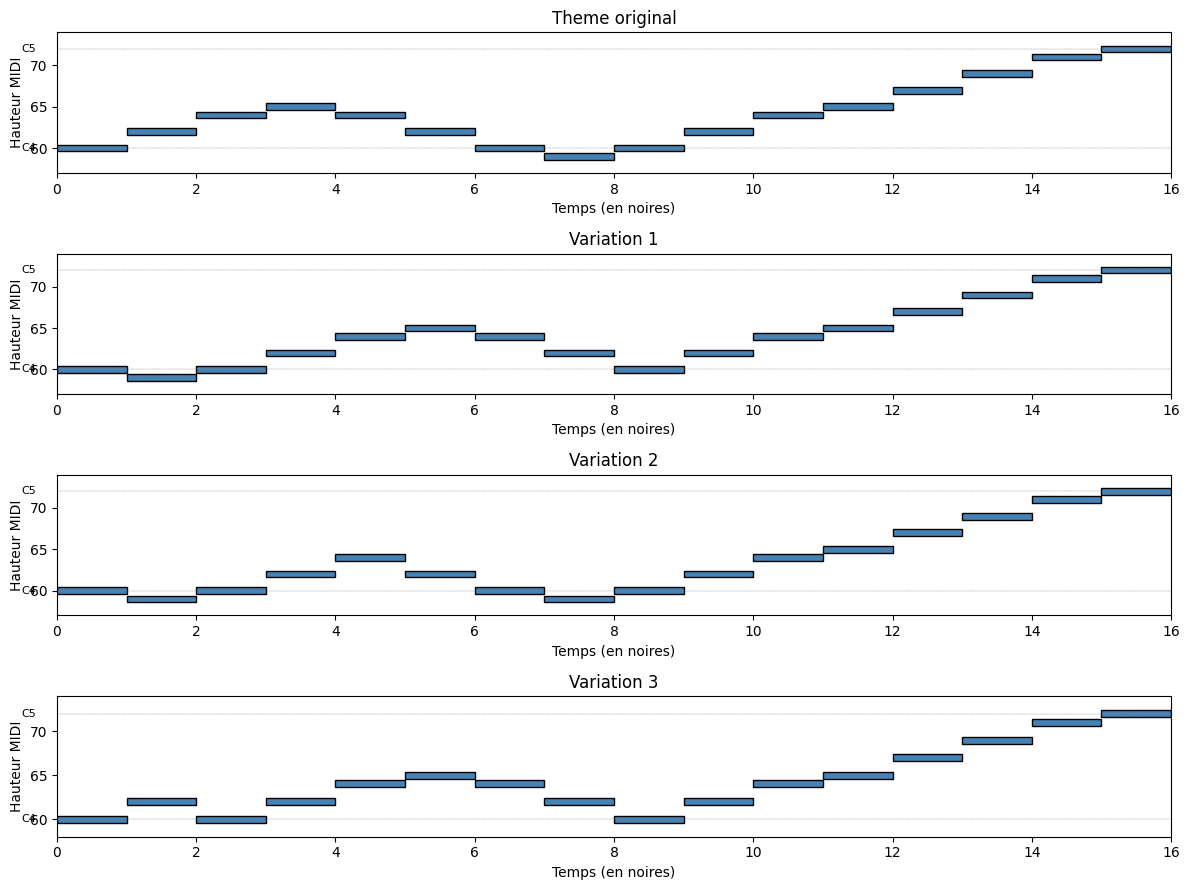

In [ ]:
from melody import (
    solve, generate_variations, solve_with_fixed_notes,
    to_text, plot_piano_roll
)
import matplotlib.pyplot as plt

theme = solve(n_notes=16, profile='fluide', random_seed=42)
print(f'Theme original : {to_text(theme)}')
print()

variations = generate_variations(theme, n_variations=3, profile='fluide')

n = len(theme)
pivot_positions = sorted(set([0, n-1, n-2] + list(range(0, n, 4))))
print(f'Positions pivots gardees : {pivot_positions}')
print()
for i, v in enumerate(variations):
    preserved = sum(1 for t in pivot_positions if v[t] == theme[t])
    print(f'Variation {i+1} : {to_text(v)}')
    print(f'  -> {preserved}/{len(pivot_positions)} pivots respectes')
    print()

fig, axes = plt.subplots(len(variations) + 1, 1, figsize=(12, 9))
plot_piano_roll(theme, title='Theme original', ax=axes[0])
for ax, var, i in zip(axes[1:], variations, range(len(variations))):
    plot_piano_roll(var, title=f'Variation {i+1}', ax=ax)
plt.tight_layout()
plt.show()


In [9]:
partial = [60, None, None, None, 64, None, None, None,
           67, None, None, None, None, None, 71, 72]

print('Notes imposees : positions [0, 4, 8, 14, 15]')
print('Theme partiel  :', ['_' if x is None else x for x in partial])
print()

result = solve_with_fixed_notes(partial, profile='fluide', random_seed=0)
print('Resolution     :', to_text(result))

# Verifier que les notes fixees sont bien la
all_fixed_ok = all(partial[t] is None or result[t] == partial[t] for t in range(len(partial)))
print(f'Toutes les notes fixees sont respectees : {all_fixed_ok}')


Notes imposees : positions [0, 4, 8, 14, 15]
Theme partiel  : [60, '_', '_', '_', 64, '_', '_', '_', 67, '_', '_', '_', '_', '_', 71, 72]

Resolution     : C4 B3 C4 D4 E4 F4 G4 A4 G4 F4 E4 F4 G4 A4 B4 C5
Toutes les notes fixees sont respectees : True


## 8. Vérification de nos contraintes

In [10]:
from melody.music_theory import SCALES

def check_melody(melody, scale_name='C_major'):
    """Verifie que la melodie respecte les hard constraints,
    et observe statistiquement le comportement des soft constraints."""
    pcs = SCALES[scale_name]['pcs']
    tonic = SCALES[scale_name]['tonic']
    triad = {pcs[0], pcs[2], pcs[4]}   # I, III, V
    n = len(melody)
    
    hard = {
        'toutes les notes dans la gamme' : all(p % 12 in pcs for p in melody),
        'premiere note = tonique'        : melody[0] % 12 == tonic,
        'derniere note = tonique'        : melody[-1] % 12 == tonic,
        'avant-derniere = V ou VII'      : melody[-2] % 12 in [pcs[4], pcs[6]],
        'sauts <= 7 demi-tons'           : all(abs(melody[t+1]-melody[t]) <= 7 for t in range(n-1)),
        'pas deux notes identiques cons.': all(melody[t] != melody[t+1] for t in range(n-1)),
        'pas de triton (6 demi-tons)'    : all(abs(melody[t+1]-melody[t]) != 6 for t in range(n-1)),
    }
    
    strong_beats = [melody[t] % 12 in triad for t in range(0, n, 2)]
    peak_pos = melody.index(max(melody))
    soft_stats = {
        'consonance temps forts (cible >70%)' : f'{100*sum(strong_beats)/len(strong_beats):.0f}%',
        f'pic melodique (cible : entre {n//3} et {2*n//3})' : f'position {peak_pos}',
    }
    
    return hard, soft_stats

m = solve(n_notes=16, profile='fluide', random_seed=3)
print('Melodie :', to_text(m))
print()
hard, soft = check_melody(m)
print('--- Hard constraints (doivent toutes etre OK) ---')
for rule, ok in hard.items():
    status = '[OK]' if ok else '[ECHEC]'
    print(f'  {status} {rule}')
print()
print('--- Soft constraints (observations statistiques) ---')
for rule, value in soft.items():
    print(f'  -> {rule} : {value}')

Melodie : C4 D4 E4 F4 G4 F4 E4 D4 C4 D4 E4 F4 G4 A4 B4 C5

--- Hard constraints (doivent toutes etre OK) ---
  [OK] toutes les notes dans la gamme
  [OK] premiere note = tonique
  [OK] derniere note = tonique
  [OK] avant-derniere = V ou VII
  [OK] sauts <= 7 demi-tons
  [OK] pas deux notes identiques cons.
  [OK] pas de triton (6 demi-tons)

--- Soft constraints (observations statistiques) ---
  -> consonance temps forts (cible >70%) : 88%
  -> pic melodique (cible : entre 5 et 10) : position 15


## 9. Conclusion

Ce qu'on a montré :

- La composition musicale **se modélise très naturellement en CSP** : variables = notes, domaines = hauteurs, contraintes = règles.
- Les **hard constraints** (gamme, intervalles, cadence, anti-triton) garantissent la validité musicale.
- Les **soft constraints** (Weighted CSP, notebook CSP-7) permettent de paramétrer le **style** sans changer le modèle.
- En **changeant uniquement les poids**, on obtient trois styles distincts et reconnaissables.
- Les soft constraints structurelles (`strong_beat`, `arch`) modélisent des préférences musicales avancées (pesanteur métrique, contour en arche) à l'aide de **variables booléennes auxiliaires** et de contraintes conditionnelles `OnlyEnforceIf`.
- Le **mode variation** illustre un problème inverse classique en CP : on fixe certaines variables (les pivots) et le solveur complète le reste — exactement comme un Sudoku partiellement rempli.
- L'**export ABC** complète le MIDI : on a maintenant à la fois l'écoute (MIDI) et la lecture (partition graphique via abcjs.net).

Ce qu'on n'a pas fait (assumé) :

- **Pas de polyphonie** — on se concentre sur les hauteurs d'une seule voix, sans contrepoint à plusieurs voix.
- **Pas de rythme variable** — toutes les notes durent une noire. La contrainte `strong_beat` simule indirectement la pesanteur métrique en supposant un 4/4 implicite.
- **Pas d'évaluation humaine** — on ne juge pas si c'est "beau", on vérifie objectivement que les règles sont respectées et on laisse le jury écouter.

Pour aller plus loin :

- Ajouter une 2e voix (basse) avec contraintes de consonance → on entre dans le **contrepoint**.
- Ajouter des durées variables → contraintes métriques (somme des durées = nombre de mesures).
- Étendre le mode variation : insertion automatique d'ornementations (notes de passage, broderies) entre les pivots.
